# BIRCH

BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies) predstavlja hijerarhijski algoritam za klasterovanje razvijen sa ciljem efikasne obrade veoma velikih skupova podataka.

Za razliku od klasicnih hijerarhijskih algoritama koji zahtevaju izracunavanje velikog broja medjusobnih rastojanja, BIRCH postepeno gradi kompaktnu hijerarhijsku reprezentaciju podataka poznatu kao **CF stablo (Clustering Feature Tree)**. Na taj nacin znacajno smanjuje memorijske i vremenske zahteve algoritma.

Osnovna ideja BIRCH algoritma sastoji se od dva koraka:

### Formiranje subklastera

Tokom prolaska kroz podatke algoritam ne cuva pojedinacne instance, vec ih grupise u manje lokalne grupe koje nazivamo subklasterima.

Svaki subklaster opisuje se pomocu tzv. Clustering Feature (CF) strukture koja sadrzi:

- broj instanci u subklasteru,
- zbir svih koordinata instanci,
- zbir kvadrata koordinata instanci.

Koriscenjem ovih informacija moguce je efikasno izracunati centroid, radijus i druge karakteristike subklastera bez cuvanja svih originalnih podataka.

### Izgradnja CF stabla

Subklasteri se organizuju u hijerarhijsku strukturu nalik stablu. Kada nova instanca stigne, algoritam pronalazi najblizi postojeci subklaster i odlucuje da li se instanca moze ukljuciti u njega.

Ukoliko bi dodavanje instance previse povecalo radijus subklastera, formira se novi subklaster. Na taj nacin stablo postepeno raste i prilagodjava se strukturi podataka.

Nakon formiranja CF stabla, subklasteri mogu biti dodatno grupisani primenom drugog algoritma klasterovanja kako bi se dobili konacni klasteri.

Glavne prednosti BIRCH algoritma su:

- veoma dobra skalabilnost na velikim skupovima podataka,
- mala memorijska potrosnja,
- mogucnost rada nad skupovima koji ne mogu lako stati u memoriju,
- znacajno brze izvrsavanje u odnosu na klasicne hijerarhijske metode.

Sa druge strane, kvalitet rezultata zavisi od izbora parametara stabla, pre svega od praga (`threshold`) koji odredjuje maksimalnu velicinu subklastera.

Zbog svoje efikasnosti BIRCH predstavlja posebno zanimljiv izbor za analizirani skup podataka koji sadrzi vise od 120000 instanci. Iako BIRCH omogucava obradu velikih skupova podataka uz manju memorijsku potrosnju od klasicnih hijerarhijskih algoritama, zbog ogranicenih hardverskih resursa i raspolozivih 8 GB RAM memorije eksperimenti su sprovedeni nad slucajnim uzorkom od 10000 instanci. Time je obezbedjeno stabilno izvrsavanje algoritma uz zadrzavanje reprezentativnog preseka originalnog skupa podataka.

In [ ]:
import pandas as pd
X_scaled = pd.read_csv("../../data/data_full_scaled.csv")

In [3]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

sample_size = min(10000, X_scaled.shape[0])
random_state = 42

sample_idx = np.random.RandomState(random_state).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

pca_samples = {}

for n_components in range(3, 11):

    pca = PCA(
        n_components=n_components,
        random_state=random_state
    )
    X_pca_full = pca.fit_transform(X_scaled)

    X_pca_sample = X_pca_full[sample_idx]

    pca_samples[f"pca_{n_components}"] = {
        "X_full": X_pca_full,
        "X_sample": X_pca_sample,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "pca_model": pca
    }

for name, data in pca_samples.items():
    print(
        name,
        "full:", data["X_full"].shape,
        "sample:", data["X_sample"].shape,
        "var:", round(data["explained_variance"], 4)
    )

pca_3 full: (123849, 3) sample: (10000, 3) var: 0.0269
pca_4 full: (123849, 4) sample: (10000, 4) var: 0.0325
pca_5 full: (123849, 5) sample: (10000, 5) var: 0.038
pca_6 full: (123849, 6) sample: (10000, 6) var: 0.0434
pca_7 full: (123849, 7) sample: (10000, 7) var: 0.0487
pca_8 full: (123849, 8) sample: (10000, 8) var: 0.0538
pca_9 full: (123849, 9) sample: (10000, 9) var: 0.0589
pca_10 full: (123849, 10) sample: (10000, 10) var: 0.0639


### Izbor parametara BIRCH algoritma

Prilikom evaluacije BIRCH algoritma koriscene su vrednosti `threshold = 0.5` i `branching_factor = 50`.

Parametar **threshold** odredjuje maksimalnu dozvoljenu velicinu subklastera koji se formiraju tokom izgradnje CF stabla. Manje vrednosti dovode do formiranja veceg broja manjih i detaljnijih subklastera, dok vece vrednosti rezultuju grubljim grupisanjem podataka. Vrednost 0.5 izabrana je kao kompromis izmedju preciznosti grupisanja i racunske efikasnosti.

Parametar **branching_factor** predstavlja maksimalan broj cvorova koje jedan cvor stabla moze da sadrzi. Vece vrednosti dovode do sirih i plicih stabala, dok manje vrednosti rezultuju dubljom hijerarhijskom strukturom. Vrednost 50 predstavlja podrazumevanu preporucenu vrednost u implementaciji biblioteke scikit-learn i omogucava efikasnu obradu velikih skupova podataka bez preteranog povecanja memorijske potrosnje.

Kako cilj ove analize nije optimizacija same strukture CF stabla, vec poredjenje BIRCH algoritma sa ostalim metodama klasterovanja, navedeni parametri zadrzani su na fiksnim vrednostima tokom svih eksperimenata. Analiza je fokusirana na uticaj broja PCA komponenti i broja klastera na kvalitet grupisanja.

In [5]:
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score
import pandas as pd

birch_results = []

for pca_dim in range(3, 11):

    X = pca_samples[f"pca_{pca_dim}"]["X_sample"]
    explained_variance = pca_samples[f"pca_{pca_dim}"]["explained_variance"]

    for k in range(2, 11):

        model = Birch(
            n_clusters=k,
            threshold=0.5,
            branching_factor=50
        )

        labels = model.fit_predict(X)

        silhouette = silhouette_score(X, labels)

        cluster_sizes = pd.Series(labels).value_counts()

        birch_results.append({
            "pca_dim": pca_dim,
            "explained_variance": explained_variance,
            "k": k,
            "silhouette": silhouette,
            "min_cluster_size": cluster_sizes.min(),
            "max_cluster_size": cluster_sizes.max(),
            "smallest_cluster_pct": cluster_sizes.min() / len(labels) * 100,
            "largest_cluster_pct": cluster_sizes.max() / len(labels) * 100
        })

birch_results = pd.DataFrame(birch_results)

birch_results.sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca_dim,explained_variance,k,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
1,3,0.026899,3,0.298444,1371,4699,13.71,46.99
2,3,0.026899,4,0.296311,1082,4699,10.82,46.99
3,3,0.026899,5,0.284980,245,4699,2.45,46.99
0,3,0.026899,2,0.281154,4699,5301,46.99,53.01
4,3,0.026899,6,0.235326,245,3327,2.45,33.27
5,3,0.026899,7,0.230980,245,3327,2.45,33.27
30,6,0.043420,5,0.214724,749,4610,7.49,46.10
6,3,0.026899,8,0.206191,245,3327,2.45,33.27
34,6,0.043420,9,0.198441,420,2360,4.20,23.60
33,6,0.043420,8,0.197437,567,2360,5.67,23.60


In [6]:
birch_results[
    birch_results["smallest_cluster_pct"] >= 3
].sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca_dim,explained_variance,k,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
1,3,0.026899,3,0.298444,1371,4699,13.71,46.99
2,3,0.026899,4,0.296311,1082,4699,10.82,46.99
0,3,0.026899,2,0.281154,4699,5301,46.99,53.01
30,6,0.043420,5,0.214724,749,4610,7.49,46.10
34,6,0.043420,9,0.198441,420,2360,4.20,23.60
33,6,0.043420,8,0.197437,567,2360,5.67,23.60
9,4,0.032507,2,0.195615,4399,5601,43.99,56.01
31,6,0.043420,6,0.190850,749,2959,7.49,29.59
15,4,0.032507,8,0.189265,372,2391,3.72,23.91
29,6,0.043420,4,0.188956,749,4610,7.49,46.10


### Analiza rezultata

Rezultati pokazuju da najbolje performanse ostvaruju modeli sa manjim brojem PCA komponenti, pri cemu se posebno izdvaja konfiguracija sa 3 komponente i 3 klastera. Ova konfiguracija ostvaruje najveci Silhouette Score od 0.298 uz relativno uravnotezenu raspodelu instanci po klasterima.

Za razliku od DBSCAN i Agglomerative algoritama, kod kojih su najbolje konfiguracije cesto formirale jedan dominantan klaster, BIRCH uspeva da izdvoji vise grupa koje sadrze znacajan procenat podataka. Najmanji klaster u najboljoj konfiguraciji obuhvata oko 14% instanci, dok najveci sadrzi oko 47%, sto ukazuje na znatno stabilniju strukturu klastera.

Takodje se moze primetiti da povecanje broja klastera uglavnom dovodi do postepenog opadanja Silhouette Score vrednosti i formiranja manjih grupa. Zbog toga konfiguracije sa vecim brojem klastera, iako detaljnije segmentiraju podatke, ne donose poboljsanje kvaliteta grupisanja.

Nakon uklanjanja konfiguracija sa veoma malim klasterima, kao najperspektivnije izdvajaju se konfiguracije sa 2, 3 i 4 klastera na PCA reprezentaciji sa 3 komponente. Medju njima, model sa 3 klastera ostvaruje najbolji odnos izmedju kvaliteta grupisanja i uravnotezenosti klastera, zbog cega je izabran za dalju analizu.

In [12]:
from sklearn.cluster import Birch

X = pca_samples["pca_3"]["X_sample"]
X_full = pca_samples["pca_3"]["X_full"] 

best_birch = Birch(
    n_clusters=3,
    threshold=0.5,
    branching_factor=50
)

labels_birch = best_birch.fit_predict(X_full)


print(X.shape)
print(labels_birch.shape)

(10000, 3)
(123849,)


In [13]:
pd.Series(labels_birch).value_counts(normalize=True) * 100

0    55.282643
1    31.911441
2    12.805917
Name: proportion, dtype: float64

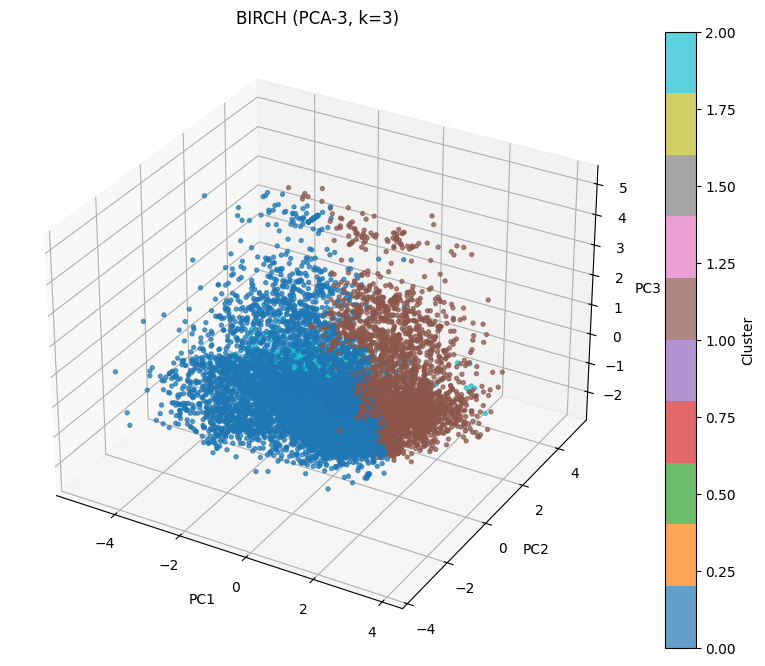

In [15]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

X = pca_samples["pca_3"]["X_sample"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=labels_birch[sample_idx],
    cmap="tab10",
    s=8,
    alpha=0.7
)

ax.set_title("BIRCH (PCA-3, k=3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, label="Cluster")

plt.show()

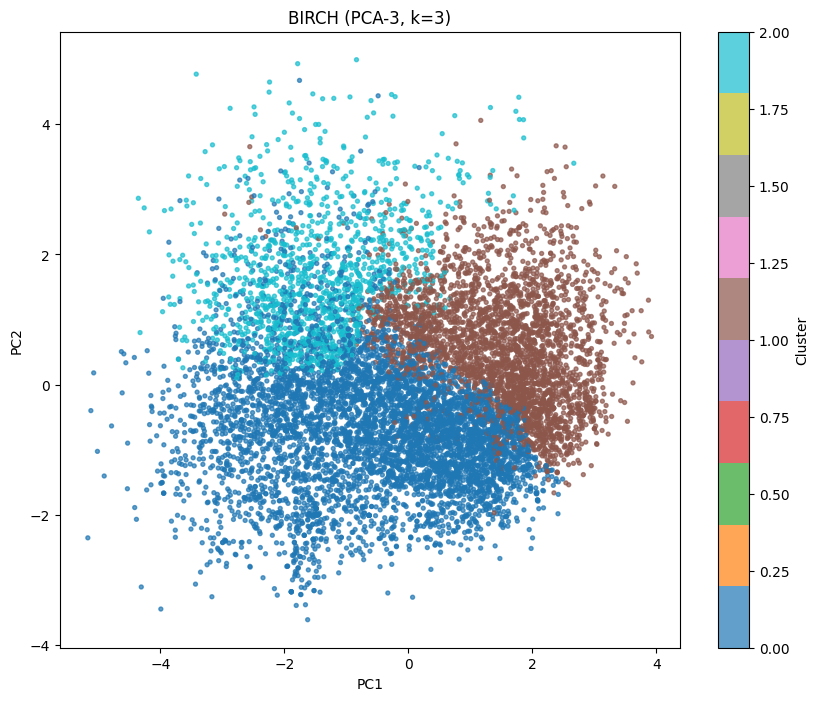

In [16]:
import matplotlib.pyplot as plt

X = pca_samples["pca_3"]["X_sample"]

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_birch[sample_idx],
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title("BIRCH (PCA-3, k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Cluster")

plt.show()

### Vizuelna analiza klastera

Vizuelizacija najboljeg BIRCH modela pokazuje da algoritam uspeva da izdvoji tri relativno jasno definisane grupe u prostoru prvih PCA komponenti.

Najveci klaster zauzima centralni i donji deo prostora, dok su preostala dva klastera uglavnom razdvojena duz druge glavne komponente. Iako postoji odredjeno preklapanje na granicama izmedju klastera, posebno u centralnim regionima prostora, osnovna struktura grupa ostaje jasno uocljiva.

Dvodimenzionalni prikaz dodatno potvrdjuje da klasteri nisu formirani kao izdvojeni outlier regioni, vec obuhvataju znacajne delove skupa podataka. Ovo je u skladu sa prethodno analiziranim raspodelama instanci koje pokazuju da nijedan klaster ne dominira skupom niti predstavlja zanemarljivo mali procenat podataka.

Na osnovu vizuelne analize moze se zakljuciti da BIRCH uspesno identifikuje osnovnu strukturu podataka i formira interpretabilne klastere, iako granice izmedju grupa nisu potpuno jasno definisane.

In [ ]:
pd.Series(labels_birch).to_csv(
    "../../models/birch_labels.csv",
    index = False
)

: 